In [53]:
import os
import hashlib
import random


import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
df=pd.read_csv("loan_data_v1.csv",sep=",")
df.head()

,Unnamed: 0,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,41282,31.0,female,High School,31903.0,10,OWN,13672.0,VENTURE,12.66,0.43,10.0,637.0,Yes,NaN
1,23717,29.0,female,NaN,39365.0,3,RENT,9250.0,HOMEIMPROVEMENT,15.65,0.23,7.0,625.0,No,1.0
2,39085,27.0,male,Bachelor,150854.0,6,MORTGAGE,15628.0,PERSONAL,9.18,0.10,4.0,633.0,No,0.0
3,37196,27.0,female,Bachelor,57474.0,6,RENT,5000.0,MEDICAL,10.36,0.09,7.0,NaN,Yes,0.0
4,21819,29.0,female,Associate,61039.0,7,MORTGAGE,10000.0,MEDICAL,7.88,0.16,8.0,673.0,Yes,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      7000 non-null   int64  
 1   person_age                      6598 non-null   float64
 2   person_gender                   6732 non-null   object 
 3   person_education                6644 non-null   object 
 4   person_income                   7000 non-null   float64
 5   person_emp_exp                  7000 non-null   int64  
 6   person_home_ownership           7000 non-null   object 
 7   loan_amnt                       6621 non-null   float64
 8   loan_intent                     7000 non-null   object 
 9   loan_int_rate                   7000 non-null   float64
 10  loan_percent_income             7000 non-null   float64
 11  cb_person_cred_hist_length      7000 non-null   float64
 12  credit_score                    66

<Axes: >

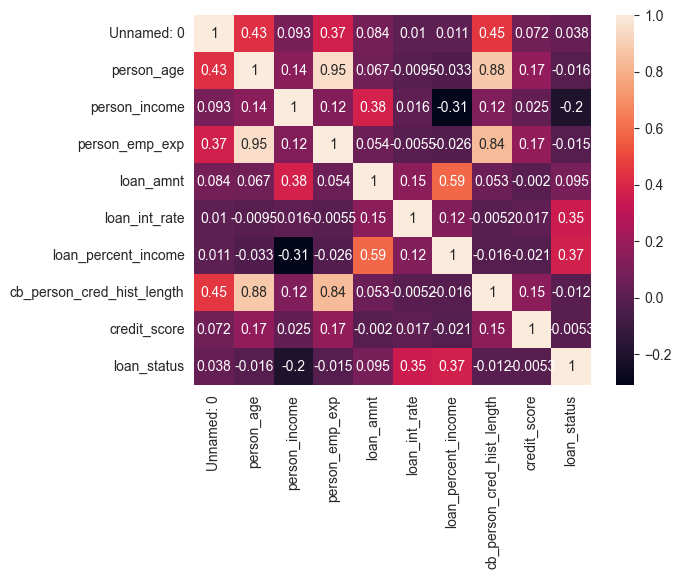

In [5]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [6]:
df.isnull().sum()

Unnamed: 0                          0
person_age                        402
person_gender                     268
person_education                  356
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                         379
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      342
previous_loan_defaults_on_file      0
loan_status                       274
dtype: int64

In [7]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [8]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,31.0,female,High School,31903.0,10,OWN,13672.0,VENTURE,12.66,0.43,10.0,637.0,Yes,NaN
1,29.0,female,NaN,39365.0,3,RENT,9250.0,HOMEIMPROVEMENT,15.65,0.23,7.0,625.0,No,1.0
2,27.0,male,Bachelor,150854.0,6,MORTGAGE,15628.0,PERSONAL,9.18,0.10,4.0,633.0,No,0.0
3,27.0,female,Bachelor,57474.0,6,RENT,5000.0,MEDICAL,10.36,0.09,7.0,NaN,Yes,0.0
4,29.0,female,Associate,61039.0,7,MORTGAGE,10000.0,MEDICAL,7.88,0.16,8.0,673.0,Yes,0.0


<Axes: >

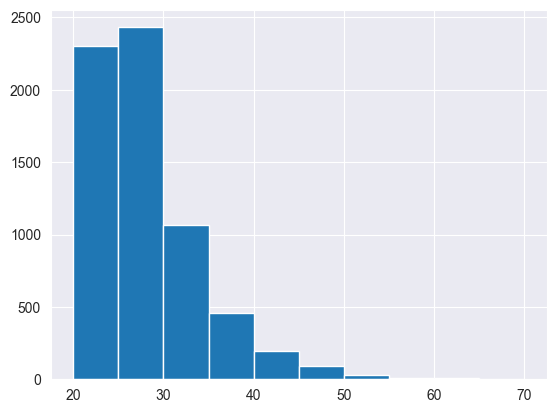

In [9]:
df['person_age'].hist()

In [16]:
df.drop(columns=['person_age'],inplace=True)


In [17]:
df.isnull().sum()

person_gender                     268
person_education                  356
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                         379
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      342
previous_loan_defaults_on_file      0
loan_status                       274
dtype: int64

<Axes: xlabel='person_gender'>

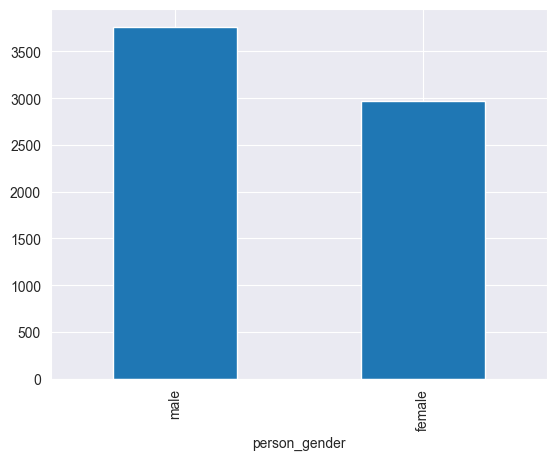

In [23]:
df['person_gender'].value_counts().plot(kind='bar')

In [26]:
label_encoder=LabelEncoder()
mode_value=df['person_gender'].mode()[0]
df['person_gender'].fillna(mode_value,inplace=True)


In [27]:
df.isnull().sum()

person_gender                       0
person_education                  356
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                         379
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      342
previous_loan_defaults_on_file      0
loan_status                       274
dtype: int64

In [28]:
df['person_education'].value_counts()

person_education
Bachelor       1902
Associate      1820
High School    1778
Master         1054
Doctorate        90
Name: count, dtype: int64

In [33]:
categories = ['High School', 'Bachelor', 'Associate', 'Master', 'Doctorate']

education_encoder=OrdinalEncoder(categories=[categories],handle_unknown='use_encoded_value',unknown_value=np.nan)
df[['person_education']]=education_encoder.fit_transform(df[['person_education']])

In [34]:
df.isnull().sum()

person_gender                       0
person_education                  356
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                         379
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      342
previous_loan_defaults_on_file      0
loan_status                       274
dtype: int64

<Axes: >

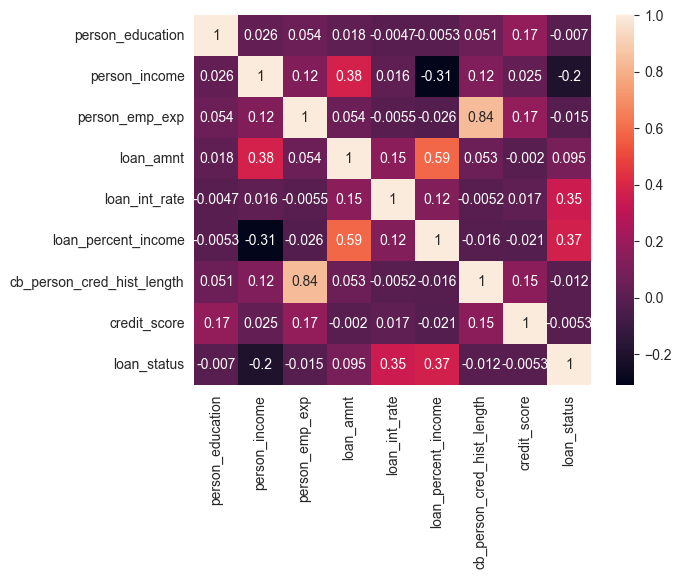

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [38]:
education_encoder.categories_

[array(['High School', 'Bachelor', 'Associate', 'Master', 'Doctorate'],
       dtype=object)]

<Axes: ylabel='Frequency'>

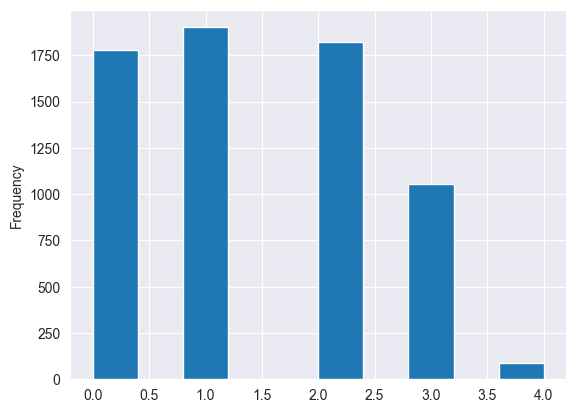

In [39]:
df['person_education'].plot.hist()

In [41]:
df['loan_amnt'].value_counts()

loan_amnt
10000.0    557
5000.0     412
12000.0    331
6000.0     320
8000.0     292
          ... 
3175.0       1
8892.0       1
6025.0       1
18195.0      1
13672.0      1
Name: count, Length: 973, dtype: int64

<Axes: ylabel='loan_amnt'>

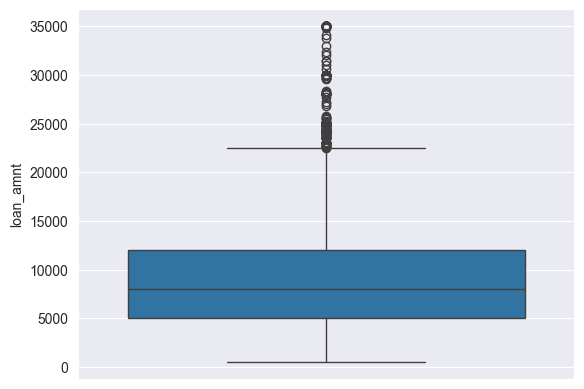

In [42]:
sns.boxplot(df['loan_amnt'])

In [43]:
knn_imputer = KNNImputer(n_neighbors=19)
imputed_col = knn_imputer.fit_transform(df[["person_education", "loan_amnt"]])
df[['person_education','loan_amnt']]=np.round(imputed_col).astype(int)

In [44]:
df.isnull().sum()

person_gender                       0
person_education                    0
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                           0
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      342
previous_loan_defaults_on_file      0
loan_status                       274
dtype: int64

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_gender                   7000 non-null   object 
 1   person_education                7000 non-null   int64  
 2   person_income                   7000 non-null   float64
 3   person_emp_exp                  7000 non-null   int64  
 4   person_home_ownership           7000 non-null   object 
 5   loan_amnt                       7000 non-null   int64  
 6   loan_intent                     7000 non-null   object 
 7   loan_int_rate                   7000 non-null   float64
 8   loan_percent_income             7000 non-null   float64
 9   cb_person_cred_hist_length      7000 non-null   float64
 10  credit_score                    6658 non-null   float64
 11  previous_loan_defaults_on_file  7000 non-null   object 
 12  loan_status                     67

In [46]:
dummies=pd.get_dummies(df['person_gender'])
df=pd.concat([df,dummies],axis=1)
df.drop(columns=['person_gender'],inplace=True)

In [47]:
df.head()

,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,female,male
0,0,31903.0,10,OWN,13672,VENTURE,12.66,0.43,10.0,637.0,Yes,NaN,True,False
1,1,39365.0,3,RENT,9250,HOMEIMPROVEMENT,15.65,0.23,7.0,625.0,No,1.0,True,False
2,1,150854.0,6,MORTGAGE,15628,PERSONAL,9.18,0.10,4.0,633.0,No,0.0,False,True
3,1,57474.0,6,RENT,5000,MEDICAL,10.36,0.09,7.0,NaN,Yes,0.0,True,False
4,2,61039.0,7,MORTGAGE,10000,MEDICAL,7.88,0.16,8.0,673.0,Yes,0.0,True,False


In [48]:
df.dropna(subset=['loan_status'],inplace=True)

In [49]:
df.isnull().sum()

person_education                    0
person_income                       0
person_emp_exp                      0
person_home_ownership               0
loan_amnt                           0
loan_intent                         0
loan_int_rate                       0
loan_percent_income                 0
cb_person_cred_hist_length          0
credit_score                      325
previous_loan_defaults_on_file      0
loan_status                         0
female                              0
male                                0
dtype: int64

In [50]:
df['credit_score'].value_counts()

credit_score
667.0    69
670.0    64
675.0    64
635.0    64
640.0    63
         ..
482.0     1
502.0     1
756.0     1
745.0     1
744.0     1
Name: count, Length: 288, dtype: int64

<Axes: >

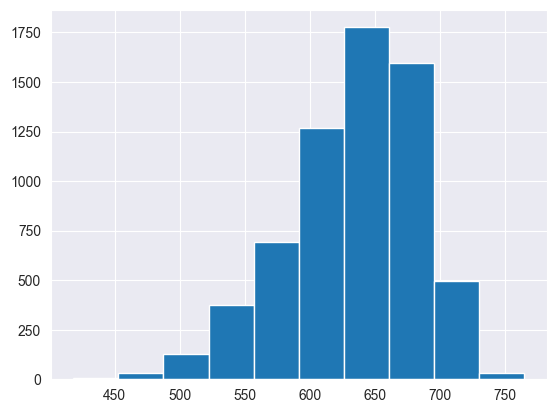

In [51]:
df['credit_score'].hist()

In [54]:
simple_imputer=SimpleImputer(strategy='median')
df['credit_score']=simple_imputer.fit_transform(df[['credit_score']])

In [56]:
df.isnull().sum()

person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
female                            0
male                              0
dtype: int64

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6726 entries, 1 to 6999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_education                6726 non-null   int64  
 1   person_income                   6726 non-null   float64
 2   person_emp_exp                  6726 non-null   int64  
 3   person_home_ownership           6726 non-null   object 
 4   loan_amnt                       6726 non-null   int64  
 5   loan_intent                     6726 non-null   object 
 6   loan_int_rate                   6726 non-null   float64
 7   loan_percent_income             6726 non-null   float64
 8   cb_person_cred_hist_length      6726 non-null   float64
 9   credit_score                    6726 non-null   float64
 10  previous_loan_defaults_on_file  6726 non-null   object 
 11  loan_status                     6726 non-null   float64
 12  female                          6726 no

In [58]:
label_encoder=LabelEncoder()
encoded_values = label_encoder.fit_transform(df["person_home_ownership"])
df['person_home_ownership']=encoded_values

In [59]:
df['person_home_ownership'].dtype

dtype('int64')

In [60]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            1386
MEDICAL              1283
DEBTCONSOLIDATION    1138
PERSONAL             1126
VENTURE              1106
HOMEIMPROVEMENT       687
Name: count, dtype: int64

In [61]:
label_encoder=LabelEncoder()
encoded_values = label_encoder.fit_transform(df["loan_intent"])
df['loan_intent']=encoded_values

In [62]:
df['loan_intent'].dtype

dtype('int64')

In [64]:
df['previous_loan_defaults_on_file'].apply(lambda x: 1 if x=='Yes' else 0)

1       0
2       0
3       1
4       1
5       1
       ..
6995    1
6996    0
6997    0
6998    0
6999    1
Name: previous_loan_defaults_on_file, Length: 6726, dtype: int64

In [72]:
train_x,test_x,train_y,test_y=train_test_split(df.drop(columns=['loan_status']),df['loan_status'])

In [65]:
model=RandomForestClassifier(
    n_estimators=500,
    random_state=42
)

In [67]:
model.fit(train_x,train_y)

ValueError: could not convert string to float: 'No'

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6726 entries, 1 to 6999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_education                6726 non-null   int64  
 1   person_income                   6726 non-null   float64
 2   person_emp_exp                  6726 non-null   int64  
 3   person_home_ownership           6726 non-null   int64  
 4   loan_amnt                       6726 non-null   int64  
 5   loan_intent                     6726 non-null   int64  
 6   loan_int_rate                   6726 non-null   float64
 7   loan_percent_income             6726 non-null   float64
 8   cb_person_cred_hist_length      6726 non-null   float64
 9   credit_score                    6726 non-null   float64
 10  previous_loan_defaults_on_file  6726 non-null   object 
 11  loan_status                     6726 non-null   float64
 12  female                          6726 no

In [70]:
df['previous_loan_defaults_on_file']=df['previous_loan_defaults_on_file'].apply(lambda x: 1 if x=='Yes' else 0)

In [73]:
model.fit(train_x,train_y)

,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
pred_y=model.predict(test_x)

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [76]:
accuracy = accuracy_score(test_y, pred_y)
precision = precision_score(test_y, pred_y)
recall = recall_score(test_y, pred_y)
f1 = f1_score(test_y, pred_y)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

Accuracy: 0.9179548156956004
Precision: 0.8575757575757575
Recall: 0.7566844919786097
F1-Score: 0.8039772727272727
